# Loading Data & Lib's

In [ ]:
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import imageio

from tqdm import tqdm
from tensorflow import keras
from sklearn.model_selection import train_test_split
from IPython.display import display, Image, clear_output
from sklearn.metrics import confusion_matrix, classification_report

# Data Loading

In [ ]:
video_paths, targets = [], []
for i, path in enumerate(glob.glob('/content/*.avi')):
    video_paths.append(path)
    targets.append(i)

In [1]:
# Rescaling & Resizing
def format_frames(frame, output_size=(224, 224)):
    frame = tf.keras.layers.Rescaling(scale= 1/255)(frame) # Rescaling b/w 0 & 1.
    frame = tf.image.resize_with_pad(frame, *output_size) # Resize according to output_size.
    return frame

In [ ]:
# Reading & Processing Frames
def frame_from_video(video_path, n_frame=10, output_size=(224, 224), frame_steps=5):
    results = []
    src = cv2.VideoCapture(video_path)

    # Check if video was opened successfully
    if not src.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return None

    # Get video length and check if it's long enough.
    video_length = int(src.get(cv2.CAP_PROP_FRAME_COUNT))
    required_length = (n_frame - 1) * frame_steps + 1
    if video_length < required_length:
        print(f"Video at {video_path} is too short. It has {video_length} frames, but at least {required_length} are needed.")
        src.release()
        return None

    # Calculate the upper bound for the random start frame.
    high_bound = video_length - required_length + 1
    start_frame = np.random.randint(0, high_bound)
    src.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    # Read frames
    ret, frame = src.read()
    if ret:
        results.append(format_frames(frame, output_size))
# For 2nd frame.
        for _ in range(n_frame - 1): # This helps to take the 3rd frame instead of 2nd consecutive frame.
            # Skip frame_steps
            for _ in range(frame_steps):
                src.read()

            ret, frame = src.read()
            if ret:
                results.append(format_frames(frame, output_size))
            else:
                # Fill with a blank frame if video ends unexpectedly
                results.append(np.zeros_like(results[0]))

    src.release()
    results = np.array(results)[..., [2, 1, 0]]

    return results

# list comprehension to handle 'None' results
features = np.array([f for f in [frame_from_video(video) for video in tqdm(video_paths)] if f is not None])
targets = np.array(targets)

100%|██████████| 3/3 [00:00<00:00,  8.63it/s]


In [ ]:
features.shape

(3, 10, 224, 224, 3)

In [ ]:
targets.shape

(3,)

# GIF Animation

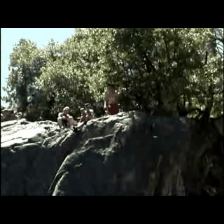

In [ ]:
# Converting frame to GIF for visulization.

def to_gif(images):
    images = np.clip(images * 255, 0, 255).astype(np.uint8)
    imageio.mimsave('./animation.gif', images, fps=10)
    display(Image(filename='./animation.gif'))

examp_video = frame_from_video(video_paths[1], n_frame= 10)
to_gif(examp_video)

# Tensorflow Pipeline

In [ ]:
import gc
train_features, val_features, train_targets, val_targets = train_test_split(features, targets, test_size=0.2, random_state=42)

# For train_dataset.
train_dataset = (tf.data.Dataset.from_tensor_slices((train_features, train_targets))
                 .shuffle(len(train_features))
                 .batch(16)
                 .cache()
                 .prefetch(tf.data.AUTOTUNE))

# For validation_dataset.
validation_dataset = (tf.data.Dataset.from_tensor_slices((val_features, val_targets))
                      .batch(16)
                      .cache()
                      .prefetch(tf.data.AUTOTUNE))

# Clean up memory
del features, targets
gc.collect()

0

In [ ]:
classes = video_paths

# Traning Model EfficientNetB0

In [ ]:
netb0 = keras.applications.EfficientNetB0(include_top= False)
netb0.trainable = False

efficient_net_model = keras.Sequential([
    keras.layers.Rescaling(255.0),
    keras.layers.TimeDistributed(netb0), # this converts each frame into features.
    keras.layers.Dense(len(classes)),
    keras.layers.GlobalAveragePooling3D()
])

efficient_net_model.compile(keras.optimizers.Adam(), loss= keras.losses.SparseCategoricalCrossentropy(from_logits= True), metrics= ['accuracy'])

history = efficient_net_model.fit(train_dataset,
                                  epochs= 10,
                                  validation_data= validation_dataset
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 137s 137s/step - accuracy: 0.5000 - loss: 0.9095 - val_accuracy: 0.0000e+00 - val_loss: 1.8196
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.5000 - loss: 0.7950 - val_accuracy: 0.0000e+00 - val_loss: 1.9761
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6914 - val_accuracy: 0.0000e+00 - val_loss: 2.1337
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.5399 - val_accuracy: 0.0000e+00 - val_loss: 2.2915
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.4715 - val_accuracy: 0.0000e+00 - val_loss: 2.4486
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.3750 - val_accuracy: 0.0000e+00 - val_loss: 2.6062
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.3374 - val_accuracy: 0.0000e+00 - val_loss: 2.7622
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accur

# Visulization

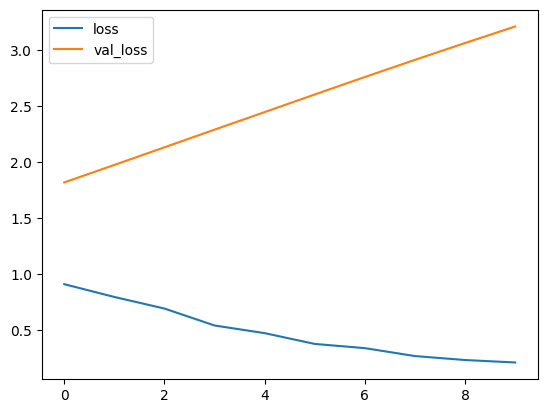

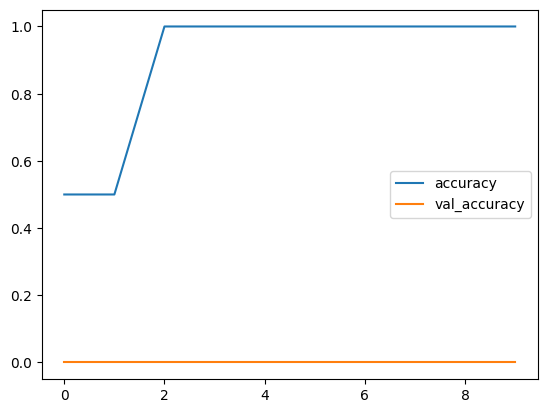

In [ ]:
for metrics in [('loss', 'val_loss'), ('accuracy', 'val_accuracy')]:
    pd.DataFrame(history.history, columns= metrics).plot()
    plt.show()

In [ ]:
val_loss , val_accuracy = efficient_net_model.evaluate(validation_dataset)
print(f'Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - accuracy: 0.0000e+00 - loss: 3.2141
Validation Loss: 3.214073657989502, Validation Accuracy: 0.0


In [ ]:
y_true = np.concatenate([y for x, y in validation_dataset], axis= 0)
# Converting logitic into class indices.
y_pred_logitcs = efficient_net_model.predict(validation_dataset)
y_pred = np.argmax(y_pred_logitcs, axis= 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
Confusion Matrix:  [[0 1]
 [0 0]]


# Confusion Matrix

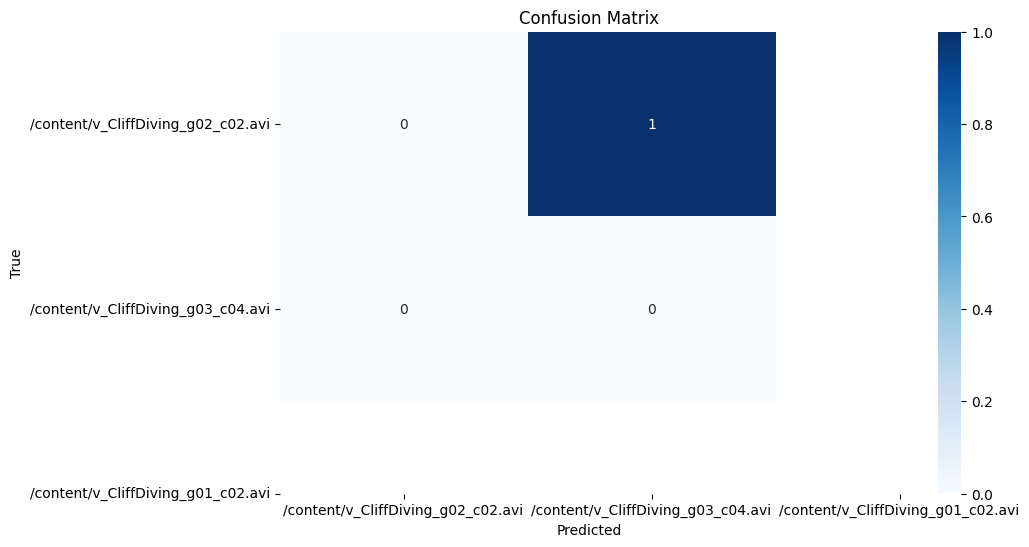

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(f'Confusion Matrix: ', cm)
plt.figure(figsize= (10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Video Detection Func

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab.patches import cv2_imshow

def detecting_video(video_path, model, classes, n_frames=10, output_size=(400, 224)):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return None

    while cap.isOpened():
        frames = []
        # Collect n_frames
        for _ in range(n_frames):
            ret, frame = cap.read()
            if not ret:
                break
            frame_resize = cv2.resize(frame, output_size)
            # Rescale frames to be between 0 and 1
            frame_resize = frame_resize / 255.0
            frames.append(frame_resize)

        # If not enough frames left, stop
        if len(frames) < n_frames:
            break

        # Prepare for prediction
        frames = np.array(frames)
        frames = np.expand_dims(frames, axis=0) # shape: (1, n_frames, h, w, c)

        predictions = model.predict(frames)
        class_idx = np.argmax(predictions)
        confidence = np.max(tf.nn.softmax(predictions)) # here, nn is a module in tf

        cap.set(cv2.CAP_PROP_POS_FRAMES, cap.get(cv2.CAP_PROP_POS_FRAMES) - 1)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, output_size)
            cv2.rectangle(frame, (20, 20), (220, 70), (0, 255, 0), 2)
            text = f'CliffDiving {confidence:.2f}'
            cv2.putText(frame, text, (25, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2_imshow(frame)

        # Stop if 'q' pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [ ]:
import PIL.Image
def display_frame(rgb):
    img = PIL.Image.fromarray(rgb)
    print(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step


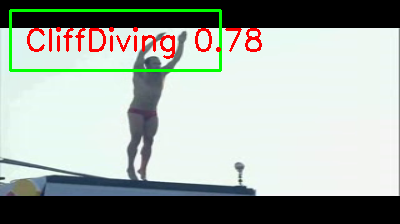

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step


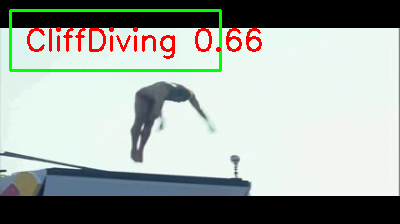

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


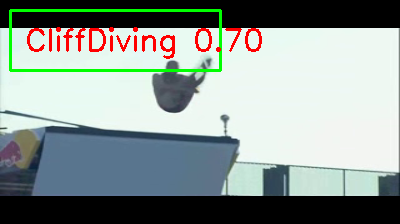

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 857ms/step


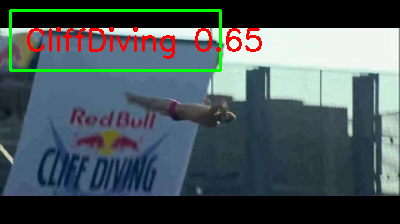

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


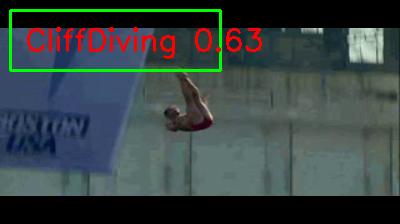

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step


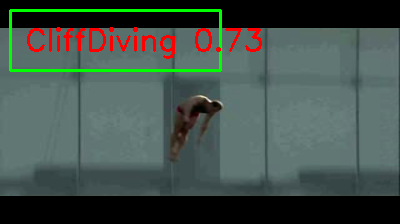

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step


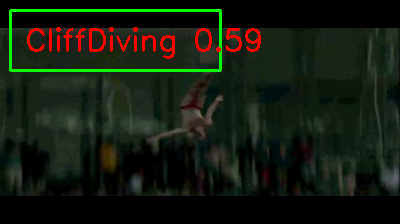

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step


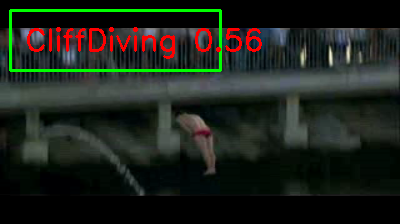

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step


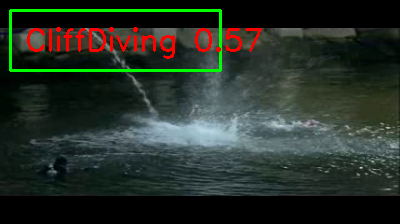

In [ ]:
examp_vid = ('/content/v_CliffDiving_g02_c02.avi')
detecting_video(examp_vid, efficient_net_model, classes, n_frames=10)